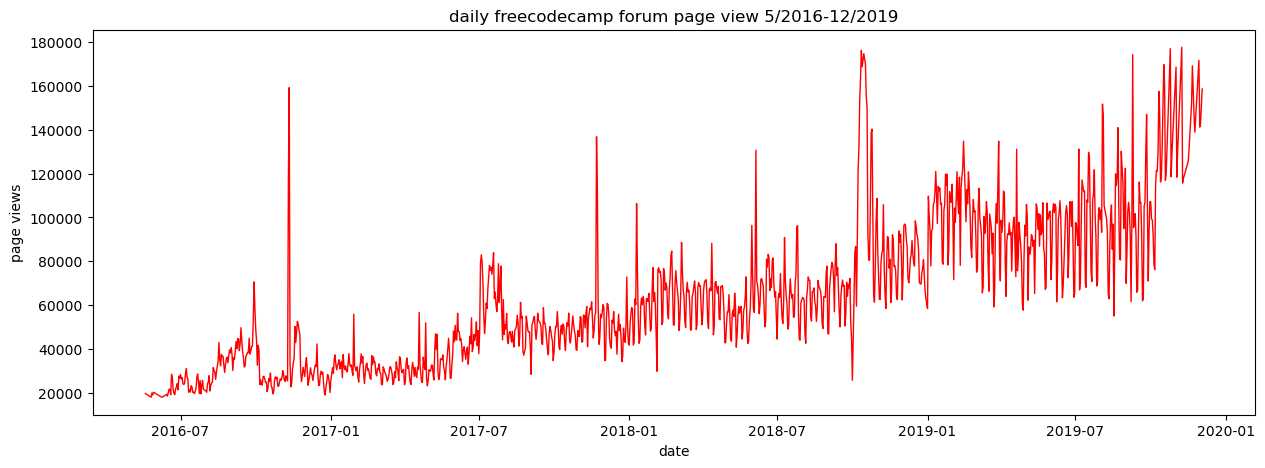

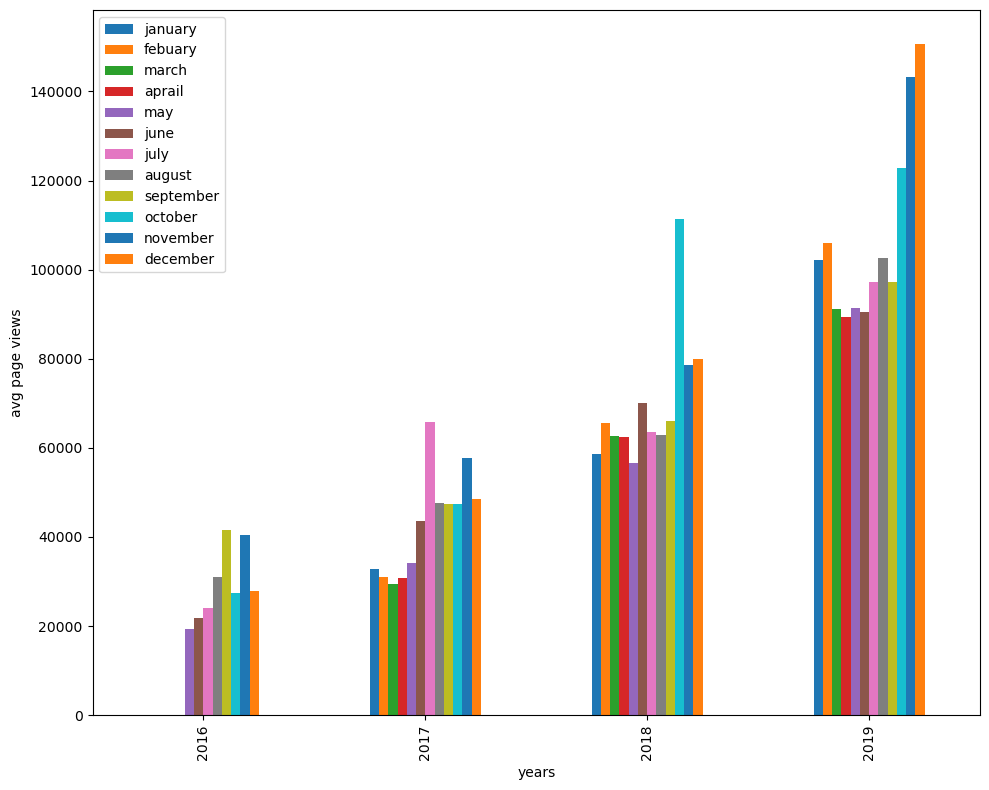

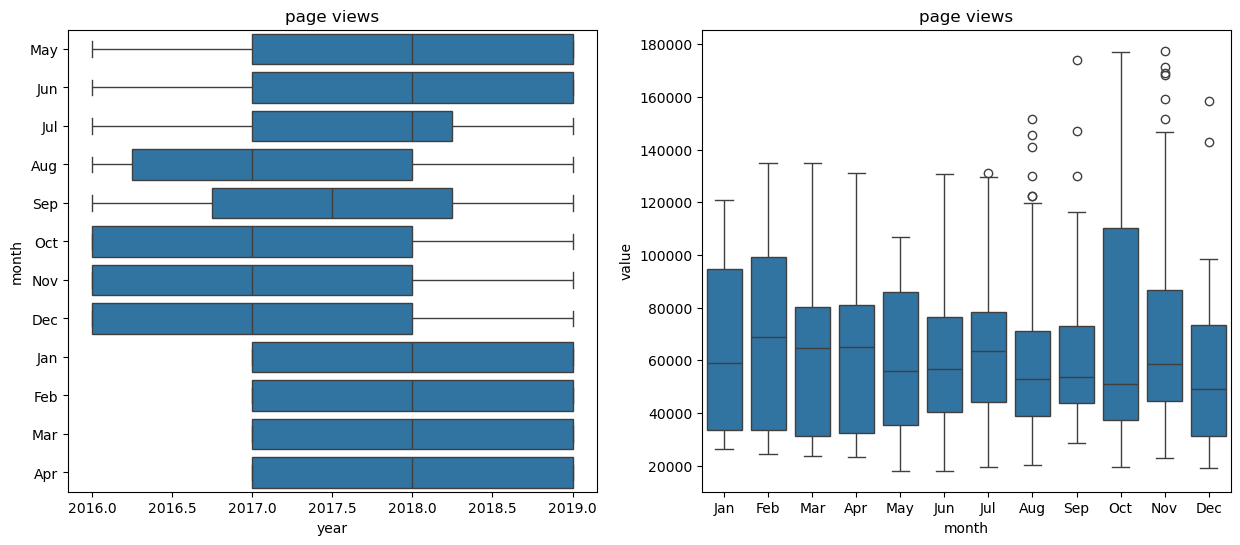

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

df = pd.read_csv('fcc-forum-pageviews.csv', parse_dates=['date'], index_col='date')
df = df[(df['value'] >= df['value'].quantile(0.025)) & (df['value'] <= df['value'].quantile(0.975))]

def draw_line_plot():
    fig, ax = plt.subplots(figsize=(15,5))
    ax.plot(df.index, df['value'],color='red',linewidth=1)
    ax.set_title('daily freecodecamp forum page view 5/2016-12/2019')
    ax.set_xlabel('date')
    ax.set_ylabel('page views')

    fig.savefig('line_plot.png')
    
def draw_bar_plot():
    df_bar = df.copy()
    df_bar['year'] = df_bar.index.year
    df_bar['month'] = df_bar.index.month
    df_bar = df_bar.groupby(['year','month'])['value'].mean().unstack()

    fig = df_bar.plot(kind='bar',figsize=(10,8)).figure
    plt.xlabel('years')
    plt.ylabel('avg page views')
    plt.legend(['january','febuary','march','aprail','may','june','july','august','september','october','november','december'])
    plt.tight_layout()
    fig.savefig('barplot.png')

def draw_box_plot():
    df_box =  df.copy()
    df_box.reset_index(inplace=True)
    df_box['year'] = df_box['date'].dt.year
    df_box['month'] = df_box['date'].dt.strftime('%b')

    month_order = list(calendar.month_abbr)[1:]

    fig, axes = plt.subplots(1,2,figsize=(15,6))

    sns.boxplot(x='year' , y='month',data=df_box,ax=axes[0])
    axes[0].set_title('year wise box plot(trend)')
    axes[0].set_title('year')
    axes[0].set_title('page views')

    sns.boxplot(x='month',y='value',data=df_box,order=month_order,ax=axes[1])
    axes[1].set_title('month wise box plot(seasonality)')
    axes[1].set_title('month')
    axes[1].set_title('page views')
    fig.savefig('box_plot.png')

draw_line_plot()
draw_bar_plot()
draw_box_plot()






